In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout,Input,LSTM,GRU
from tensorflow.keras.models import Sequential,Model

2026-06-17 04:07:22.668127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781669242.690959     292 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781669242.698500     292 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781669242.717028     292 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781669242.717047     292 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781669242.717050     292 computation_placer.cc:177] computation placer alr

In [2]:
import pandas as pd

In [3]:
from sklearn.model_selection import train_test_split

data = pd.read_csv("/kaggle/input/datasets/krishbaisoya/tweets-sentiment-analysis/train_data.csv")
data.head()

,sentence,sentiment
0,awww that s a bummer you shoulda got david car...,0
1,is upset that he can t update his facebook by ...,0
2,i dived many times for the ball managed to sav...,0
3,my whole body feels itchy and like its on fire,0
4,no it s not behaving at all i m mad why am i h...,0


In [4]:
x = data['sentence']
y = data['sentiment']

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:

from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [8]:
tok = Tokenizer()
tok.fit_on_texts(x_train)
vocab_size = len(tok.word_index) + 1
print(vocab_size)   

232299


In [9]:
sequences_x_tr = tok.texts_to_sequences(x_train)
sequences_x_test = tok.texts_to_sequences(x_test)

In [10]:
max =0
for i in range(len(sequences_x_tr)):
    if len(sequences_x_tr[i]) > max:
        max = len(sequences_x_tr[i])

print(max)


52


In [11]:
sequences_x_tr = pad_sequences(sequences_x_tr, maxlen=100)
sequences_x_test = pad_sequences(sequences_x_test, maxlen=100)

In [12]:
model = Sequential([
        Input(shape=(sequences_x_tr.shape[1],)),
        
        Embedding(input_dim=vocab_size, output_dim=128),

        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1, activation='sigmoid')



])

 


I0000 00:00:1781669286.593083     292 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │    29,734,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,915,329 (114.12 MB)

 Trainable params: 29,915,329 (114.12 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
history=  model.fit(sequences_x_tr, y_train, epochs=2, batch_size=32, validation_data=(sequences_x_test, y_test), callbacks=[checkpoint])

Epoch 1/2


I0000 00:00:1781669291.006690     331 cuda_dnn.cc:529] Loaded cuDNN version 91002


38099/38100 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7937 - loss: 0.4413
Epoch 1: val_accuracy improved from None to 0.82595, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
38100/38100 ━━━━━━━━━━━━━━━━━━━━ 807s 21ms/step - accuracy: 0.8116 - loss: 0.4125 - val_accuracy: 0.8259 - val_loss: 0.3860
Epoch 2/2
38098/38100 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8497 - loss: 0.3444
Epoch 2: val_accuracy did not improve from 0.82595
38100/38100 ━━━━━━━━━━━━━━━━━━━━ 799s 21ms/step - accuracy: 0.8516 - loss: 0.3411 - val_accuracy: 0.8248 - val_loss: 0.3936


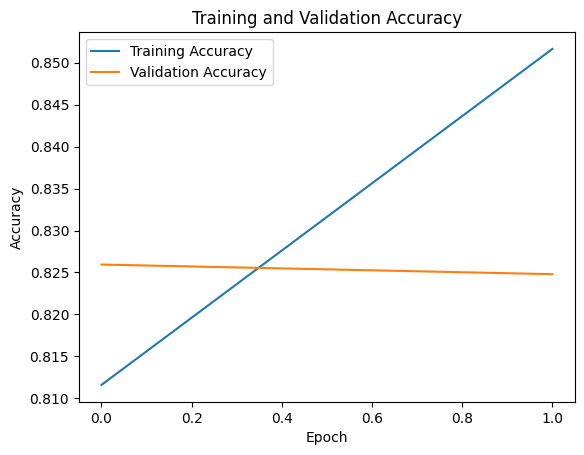

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [17]:
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tok, f)